In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

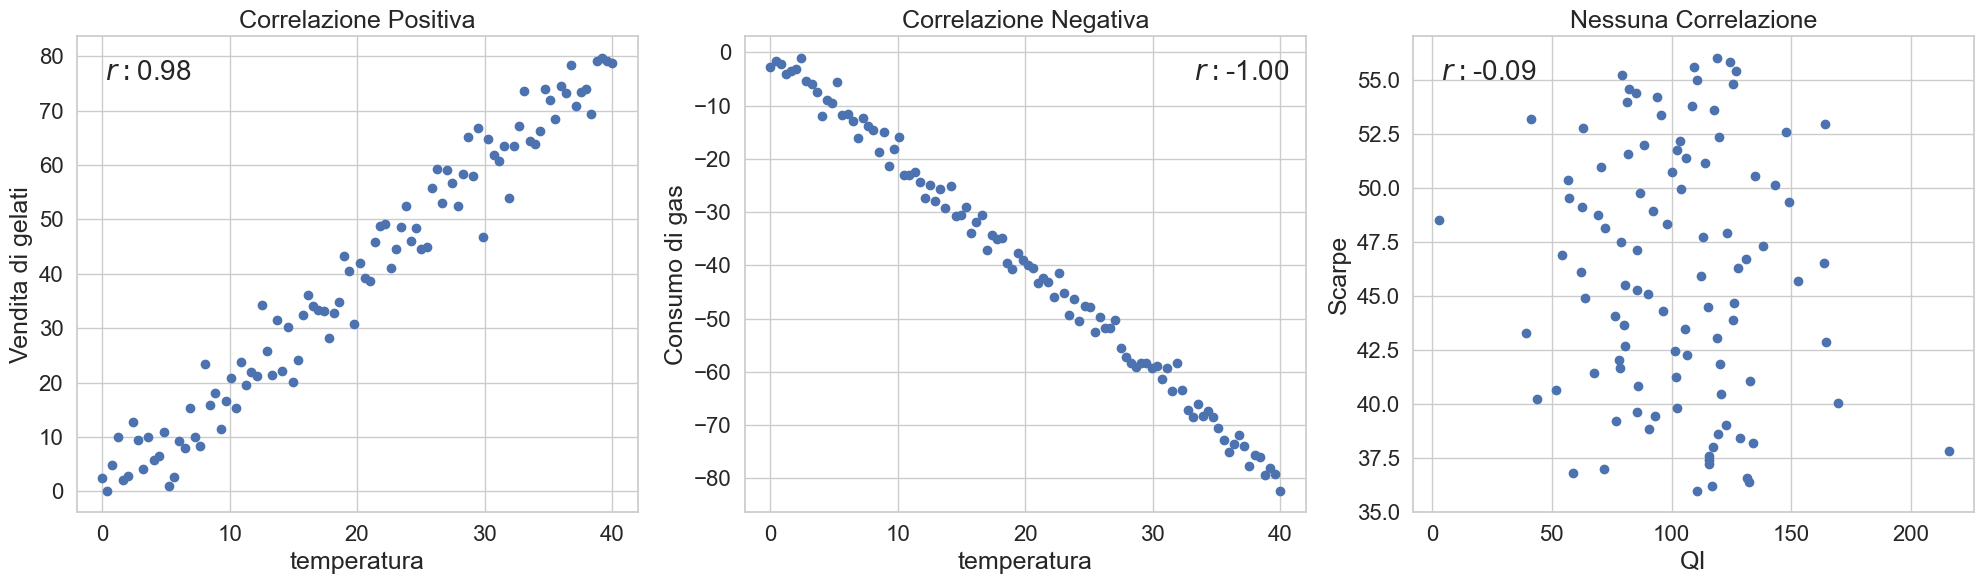

In [2]:

# Set the style
sns.set_theme(style="whitegrid")

#set plot parameters
plt.rcParams.update({
    'axes.titlesize': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 12,
    'figure.figsize': (20, 6)
})

# Generate sample data
np.random.seed(42)
temperatura = np.linspace(0, 40, 100)

# Positive correlation
y_pos = 2 * temperatura + np.random.normal(0, 5, size=temperatura.shape)

# Negative correlation
y_neg = -2 * temperatura + np.random.normal(0, 2, size=temperatura.shape)

# No correlation
scarpe = np.linspace(36, 56, 100)
y_none = np.random.normal(100, 30 ,size=scarpe.shape)
#copmpute correlation
correlazione_pos = np.corrcoef(temperatura, y_pos)[0, 1]
correlazione_neg = np.corrcoef(temperatura, y_neg)[0, 1]
correlazione_none = np.corrcoef(scarpe, y_none)[0, 1]
# Create the plots
fig, axes = plt.subplots(1, 3)

# Positive correlation plot
axes[0].scatter(temperatura, y_pos)
axes[0].set_title('Correlazione Positiva')
axes[0].set_xlabel('temperatura')
axes[0].set_ylabel('Vendita di gelati')
#add correlation value to the plot
axes[0].text(0.05, 0.95, f'$r: ${correlazione_pos:.2f}', transform=axes[0].transAxes, fontsize=20, verticalalignment='top')

# Negative correlation plot
axes[1].scatter(temperatura, y_neg)
axes[1].set_title('Correlazione Negativa')
axes[1].set_xlabel('temperatura')
axes[1].set_ylabel('Consumo di gas')
axes[1].text(0.8, 0.95, f'$r: ${correlazione_neg:.2f}', transform=axes[1].transAxes, fontsize=20, verticalalignment='top')
# No correlation plot
axes[2].scatter(y_none, scarpe)
axes[2].set_title('Nessuna Correlazione')
axes[2].set_xlabel('QI')
axes[2].set_ylabel('Scarpe')
axes[2].text(0.05, 0.95, f'$r: ${correlazione_none:.2f}', transform=axes[2].transAxes, fontsize=20, verticalalignment='top')

plt.tight_layout()
plt.show()



In [3]:
#add an outlier to X in positive correlation
#generete outliers
import pandas as pd
from scipy.stats import rankdata, pearsonr

# Dati di esempio: 15 coppie

Y = np.array([x for x in range(20,20+16)])  # Y values
Y = np.array(Y[::-1])  # Y values with some noise
X = np.array([(x+2*x**2 +np.random.exponential(30))/10 for x in range(4,20)])  # X values
# Calcolo Pearson
pearson_corr, _ = pearsonr(X, Y)

def spearman_rho_fnc(X, Y):
    """
    Calcola il coefficiente di correlazione di Spearman tra due array.
    """
    if len(X) != len(Y):
        raise ValueError("X e Y devono avere la stessa lunghezza.")
    
    # Calcolo dei ranghi
    rank_X = rankdata(X)
    rank_Y = rankdata(Y)
    
    # Calcolo Spearman
    d = rank_X - rank_Y
    d_squared = d ** 2
    n = len(X)
    
    return 1 - (6 * np.sum(d_squared)) / (n * (n**2 - 1))
spearman_rho= spearman_rho_fnc(X, Y)


rank_X = rankdata(X)
rank_Y = rankdata(Y)
d = rank_X - rank_Y
d_squared = d ** 2

# Calcolo Spearman


# Tabella con i dati e i calcoli
df = pd.DataFrame({
    "X": X,
    "Y": Y,
    "Rank_X": rank_X,
    "Rank_Y": rank_Y,
    "d = Rank_X - Rank_Y": d,
    "d^2": d_squared
})

pearson_corr, spearman_rho





(-0.9784302557294029, -0.9911764705882353)

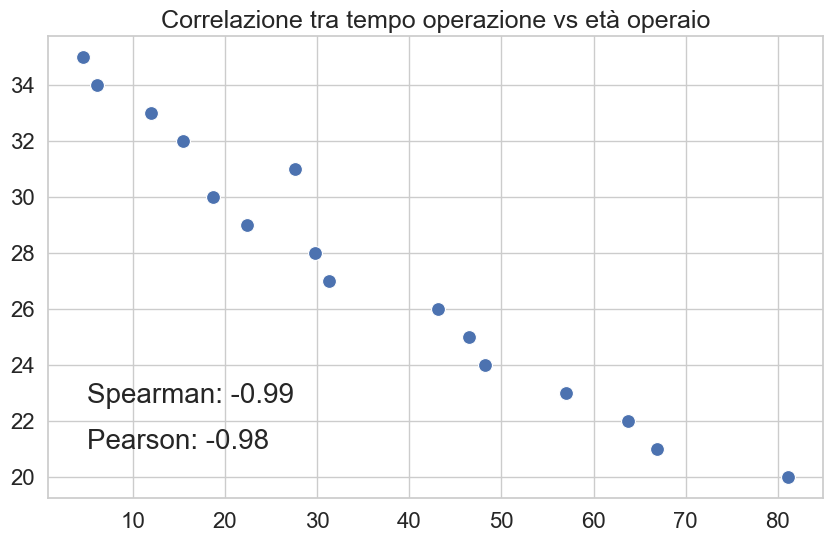

In [4]:
sns.light_palette("#79C")

plt.figure(figsize=(10, 6))
plt.title('Correlazione tra tempo operazione vs età operaio')
sns.scatterplot(x=X, y=Y, s=100)
plt.text(0.05, 0.15, f'Pearson: {pearson_corr:.2f}',
         transform=plt.gca().transAxes, fontsize=20, verticalalignment='top')
plt.text(0.05, 0.25, f'Spearman: {spearman_rho:.2f}',
         transform=plt.gca().transAxes, fontsize=20, verticalalignment='top')
plt.show()

In [5]:
# Add an outlier to Y in the positive correlation
mid = len(Y)-1
Y[mid] =  Y[mid]*1.5

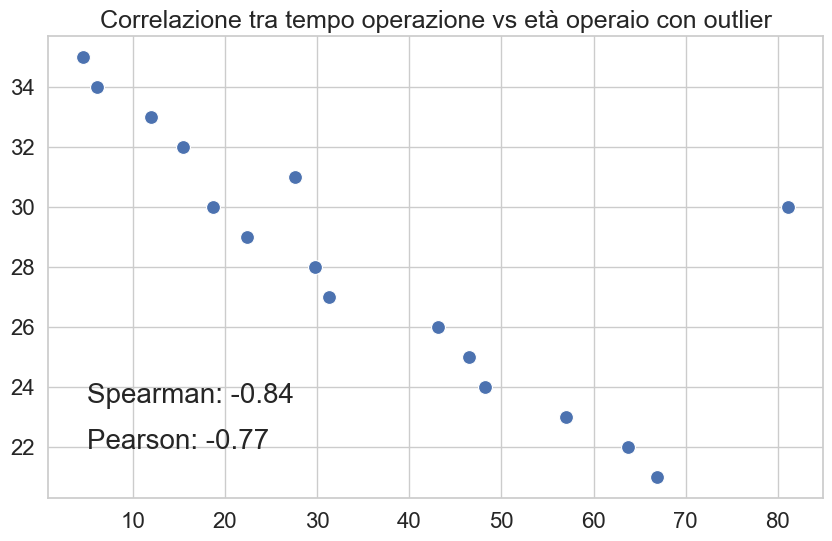

In [6]:
spearman_rho_outlier = spearman_rho_fnc(X, Y)
pearson_corr_outlier, _ = pearsonr(X, Y)
plt.figure(figsize=(10, 6))
plt.title('Correlazione tra tempo operazione vs età operaio con outlier')
sns.scatterplot(x=X, y=Y, s=100)
plt.text(0.05, 0.15, f'Pearson: {pearson_corr_outlier:.2f}',
         transform=plt.gca().transAxes, fontsize=20, verticalalignment='top')
plt.text(0.05, 0.25, f'Spearman: {spearman_rho_outlier:.2f}',
         transform=plt.gca().transAxes, fontsize=20, verticalalignment='top')
plt.show()
